# Face Recognition: RetinaFace → Align → ArcFace

Run recognition step by step, without the FaceAnalyzer wrapper:

RetinaFace: Detects faces and extracts 5-point landmarks.
Face Alignment: Warps each face into a standardized 112x112 crop using the landmarks.
ArcFace: Generates a 512-D L2-normalized embedding from the aligned crop. We compare three test images: image0.jpg, image1.jpg, and image5.jpg.

In [1]:
%pip install -q "uniface[cpu]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 11.6 MB/s eta 0:00:00


# 2. ارفع الصور في Colab

In [2]:
from google.colab import files

uploaded = files.upload()

Saving ed698783f094f687dfc423cb3db97af0.jpg to ed698783f094f687dfc423cb3db97af0.jpg
Saving OIP (2).webp to OIP (2).webp
Saving OIP.webp to OIP.webp
Saving OIP (1).webp to OIP (1).webp


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import uniface
from uniface.detection import RetinaFace
from uniface.recognition import ArcFace
from uniface.face_utils import face_alignment

print(f"UniFace version: {uniface.__version__}")

UniFace version: 4.0.0


In [6]:
IMAGE_PATHS = {
    "person_a_2010": "ed698783f094f687dfc423cb3db97af0.jpg",
    "person_a_2014": "OIP (2).webp",
    "person_a_2024": "OIP.webp",
    "person_b": "OIP (1).webp",
}

THRESHOLD = 0.4

## 1. Load Images & Detect Faces

We use the detector to find faces and their landmarks in each image.

In [7]:
images = {}
faces = {}

for name, path in IMAGE_PATHS.items():
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Cannot read: {path}")

    detected = detector.detect(img)
    if not detected:
        raise RuntimeError(f"No face detected in: {path}")

    images[name] = img
    faces[name] = detected[0]   # Keep highest-confidence face
    print(f"{name} | {len(detected)} face(s) detected | confidence={faces[name].confidence:.3f}")

person_a_2010 | 1 face(s) detected | confidence=1.000
person_a_2014 | 1 face(s) detected | confidence=1.000
person_a_2024 | 1 face(s) detected | confidence=1.000
person_b | 1 face(s) detected | confidence=1.000


# 2. Visualize **Detections**

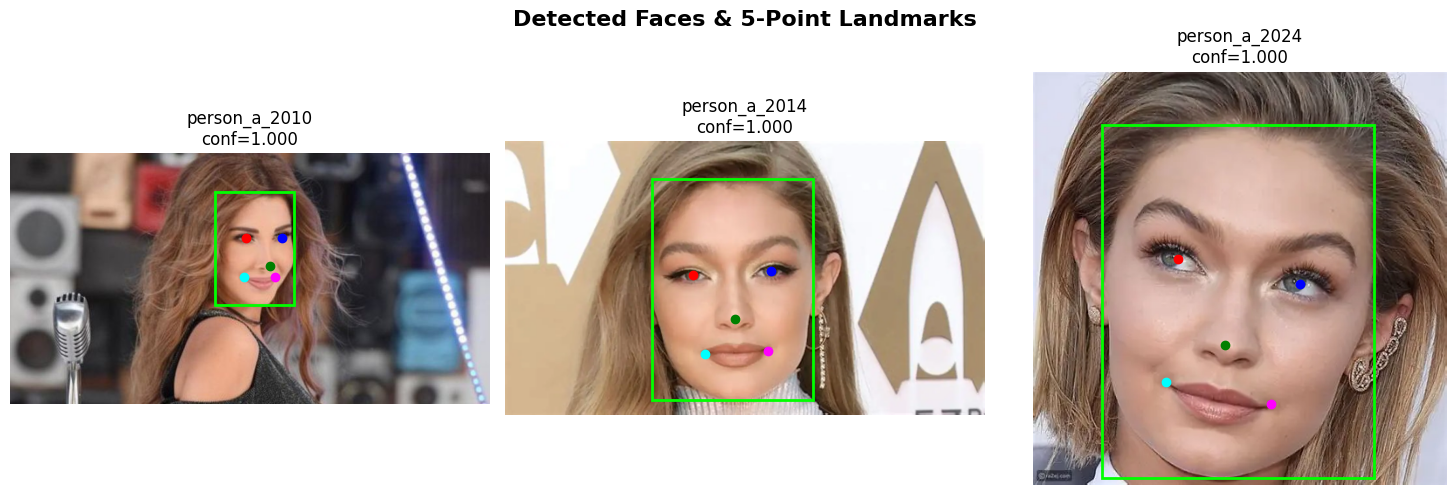

In [8]:
LM_COLORS = ["red", "blue", "green", "cyan", "magenta"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Detected Faces & 5-Point Landmarks", fontweight="bold", fontsize=16)

for ax, (name, img) in zip(axes, images.items()):
    face = faces[name]
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name}\nconf={face.confidence:.3f}", fontsize=12)
    ax.axis("off")

    # Bounding box
    x1, y1, x2, y2 = face.bbox.astype(int)
    ax.add_patch(patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor="lime", facecolor="none"))

    # Landmarks
    for (lx, ly), c in zip(face.landmarks, LM_COLORS):
        ax.plot(lx, ly, "o", color=c, markersize=6)

plt.tight_layout()
plt.show()

## 3. Face Alignment

We warp the detected faces into a standardized 112x112 size. This improves recognition accuracy.

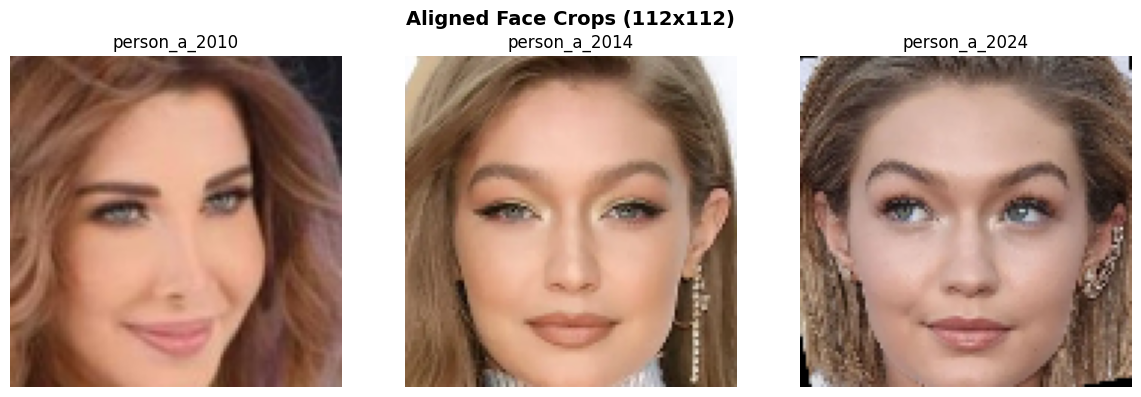

In [9]:
aligned = {}

for name, img in images.items():
    lm = faces[name].landmarks
    crop, _ = face_alignment(img, lm, image_size=(112, 112))
    aligned[name] = crop

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Aligned Face Crops (112x112)", fontweight="bold", fontsize=14)

for ax, (name, crop) in zip(axes, aligned.items()):
    ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    ax.set_title(name, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

4. Extract Embeddings
# **We pass the aligned crops to ArcFace to get the 512-D vectors.**

In [10]:
embeddings = {}

for name, crop in aligned.items():
    # landmarks=None because image is already aligned
    emb = recognizer.get_normalized_embedding(crop, landmarks=None)
    embeddings[name] = emb
    print(f"{name} | embedding shape={emb.shape} | L2-norm={np.linalg.norm(emb):.4f}")

person_a_2010 | embedding shape=(512,) | L2-norm=1.0000
person_a_2014 | embedding shape=(512,) | L2-norm=1.0000
person_a_2024 | embedding shape=(512,) | L2-norm=1.0000
person_b | embedding shape=(512,) | L2-norm=1.0000


**5. Pairwise Cosine Similarity**
# Since embeddings are normalized, cosine similarity is just the dot product

In [11]:
names = list(embeddings.keys())
n = len(names)
sim_matrix = np.zeros((n, n))

for i, ni in enumerate(names):
    for j, nj in enumerate(names):
        # Use squeeze() to handle (1, 512) shapes if present
        sim_matrix[i, j] = float(np.dot(embeddings[ni].squeeze(), embeddings[nj].squeeze()))

# Print comparison results
pairs = [(names[i], names[j]) for i in range(n) for j in range(i + 1, n)]
for a, b in pairs:
    s = float(np.dot(embeddings[a].squeeze(), embeddings[b].squeeze()))
    verdict = "✓ Same person" if s >= THRESHOLD else "✗ Different people"
    print(f"{a} vs {b}: similarity={s:.4f} → {verdict}")

person_a_2010 vs person_a_2014: similarity=0.0550 → ✗ Different people
person_a_2010 vs person_a_2024: similarity=-0.0596 → ✗ Different people
person_a_2010 vs person_b: similarity=-0.0367 → ✗ Different people
person_a_2014 vs person_a_2024: similarity=0.7373 → ✓ Same person
person_a_2014 vs person_b: similarity=0.7261 → ✓ Same person
person_a_2024 vs person_b: similarity=0.7053 → ✓ Same person


# 6. Similarity Heatmap

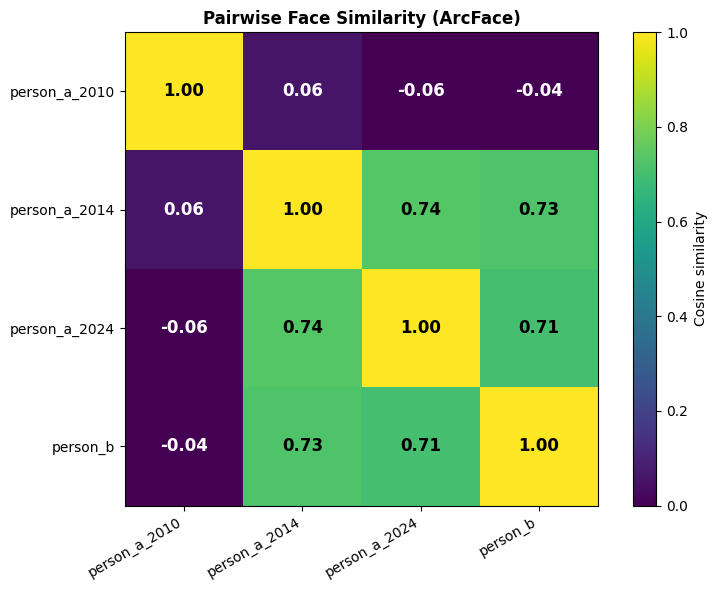

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_matrix, vmin=0, vmax=1, cmap="viridis")
plt.colorbar(im, ax=ax, label="Cosine similarity")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_yticklabels(names)
ax.set_title("Pairwise Face Similarity (ArcFace)", fontweight="bold")

for i in range(n):
    for j in range(n):
        val = sim_matrix[i, j]
        ax.text(j, i, f"{val:.2f}",
                ha="center", va="center",
                color="black" if val >= 0.6 else "white",
                fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

Notes
The diagonal of the matrix is each face against itself, so it reads 1.00. The gap between the genuine pairs and the impostor pairs is the number that matters, not any single score. **bold text**
# **Pick the threshold from known pairs in your own data.**